<a href="https://colab.research.google.com/github/ashwath161097-techi/python-data-visualization/blob/main/Data_Visualization_Matplotlib_and_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**DATA IMPORTING AND EXPLORATION**

Loading the Taxis Dataset

In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = sns.load_dataset("taxis")

# Display first rows
print(df.head())

               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South      Manhattan       Manhattan  
1  Upper West Side South      

**Handling Missing Values**

Check Missing Values

In [2]:
print(df.isnull().sum())

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


Impute Missing Values

In [3]:
# Numerical columns
df['distance'].fillna(df['distance'].mean(), inplace=True)
df['fare'].fillna(df['fare'].median(), inplace=True)

# Categorical columns
df['payment'].fillna(df['payment'].mode()[0], inplace=True)

/tmp/ipykernel_8943/807256967.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['distance'].fillna(df['distance'].mean(), inplace=True)
/tmp/ipykernel_8943/807256967.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

Drop Critical Missing Rows

In [4]:
df.dropna(subset=['pickup', 'dropoff'], inplace=True)

**Visualizations using Matplotlib / Pandas Plot**

Line Chart – Fare Over Time

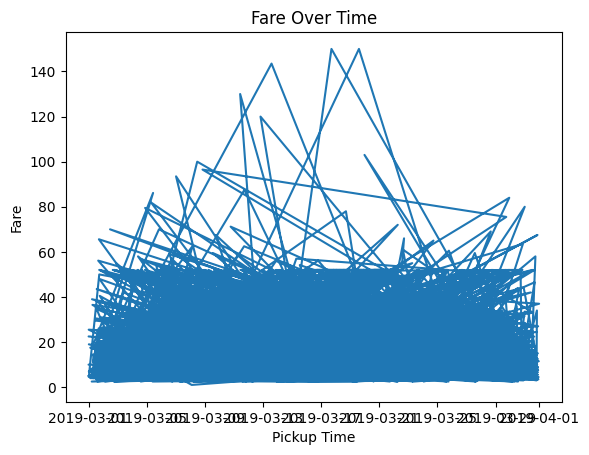

In [5]:
df['pickup'] = pd.to_datetime(df['pickup'])

plt.figure()
plt.plot(df['pickup'], df['fare'])
plt.xlabel("Pickup Time")
plt.ylabel("Fare")
plt.title("Fare Over Time")
plt.show()

Bar Chart – Total Fare by Pickup Borough

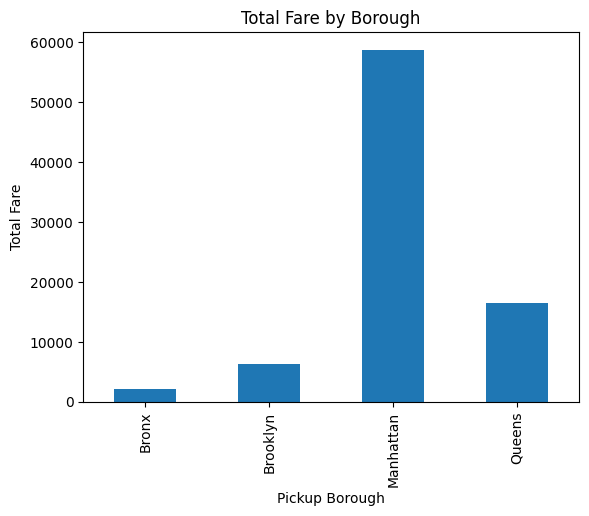

In [6]:
fare_by_borough = df.groupby('pickup_borough')['fare'].sum()

plt.figure()
fare_by_borough.plot(kind='bar')
plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare")
plt.title("Total Fare by Borough")
plt.show()

Pie Chart – Payment Method Distribution

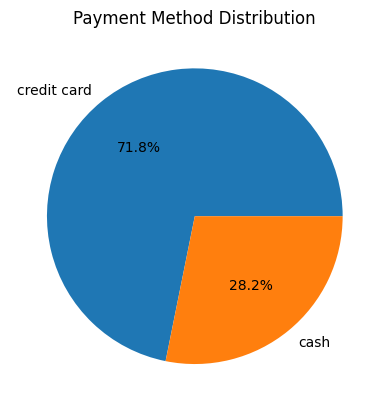

In [7]:
payment_counts = df['payment'].value_counts()

plt.figure()
payment_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()

Histogram – Distance Distribution

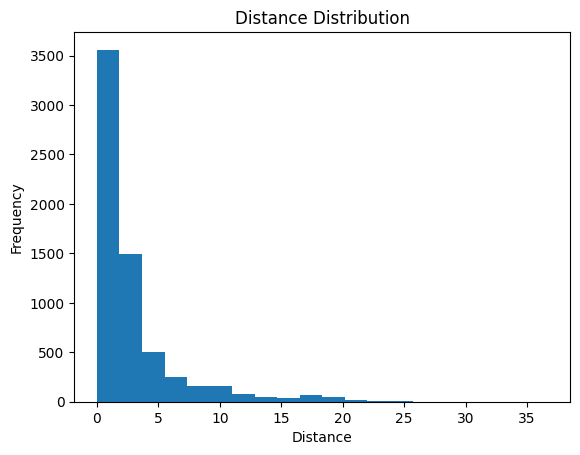

In [8]:
plt.figure()
plt.hist(df['distance'], bins=20)
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.title("Distance Distribution")
plt.show()

Box Plot – Tip by Pickup Borough

<Figure size 640x480 with 0 Axes>

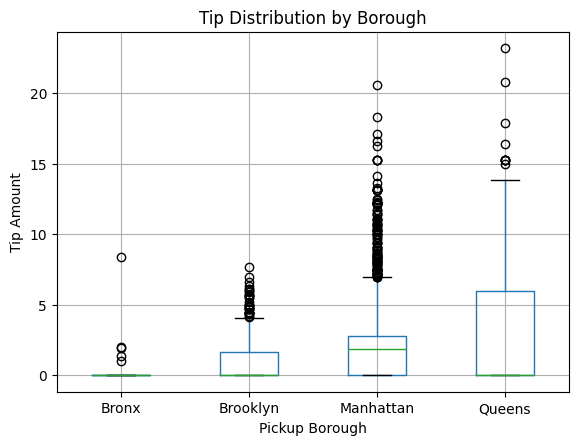

In [9]:
plt.figure()
df.boxplot(column='tip', by='pickup_borough')
plt.xlabel("Pickup Borough")
plt.ylabel("Tip Amount")
plt.title("Tip Distribution by Borough")
plt.suptitle("")
plt.show()

**Visualizations using Seaborn**

Count Plot – Trips per Borough

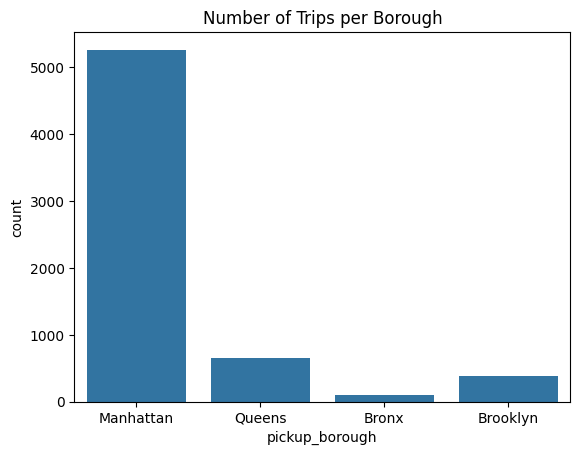

In [10]:
import seaborn as sns

plt.figure()
sns.countplot(x='pickup_borough', data=df)
plt.title("Number of Trips per Borough")
plt.show()

Scatter Plot – Distance vs Fare

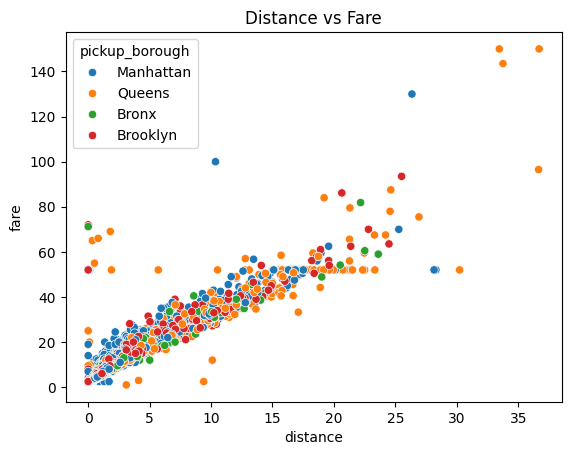

In [11]:
plt.figure()
sns.scatterplot(
    x='distance',
    y='fare',
    hue='pickup_borough',
    data=df
)
plt.title("Distance vs Fare")
plt.show()

Heatmap – Correlation Matrix

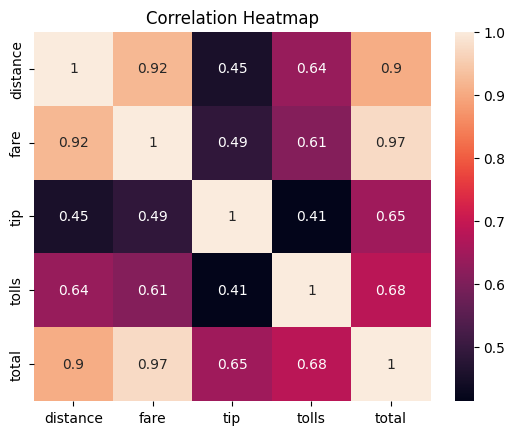

In [12]:
plt.figure()

correlation = df[['distance', 'fare', 'tip', 'tolls', 'total']].corr()

sns.heatmap(correlation, annot=True)
plt.title("Correlation Heatmap")
plt.show()

Pair Plot – Relationships Between Variables

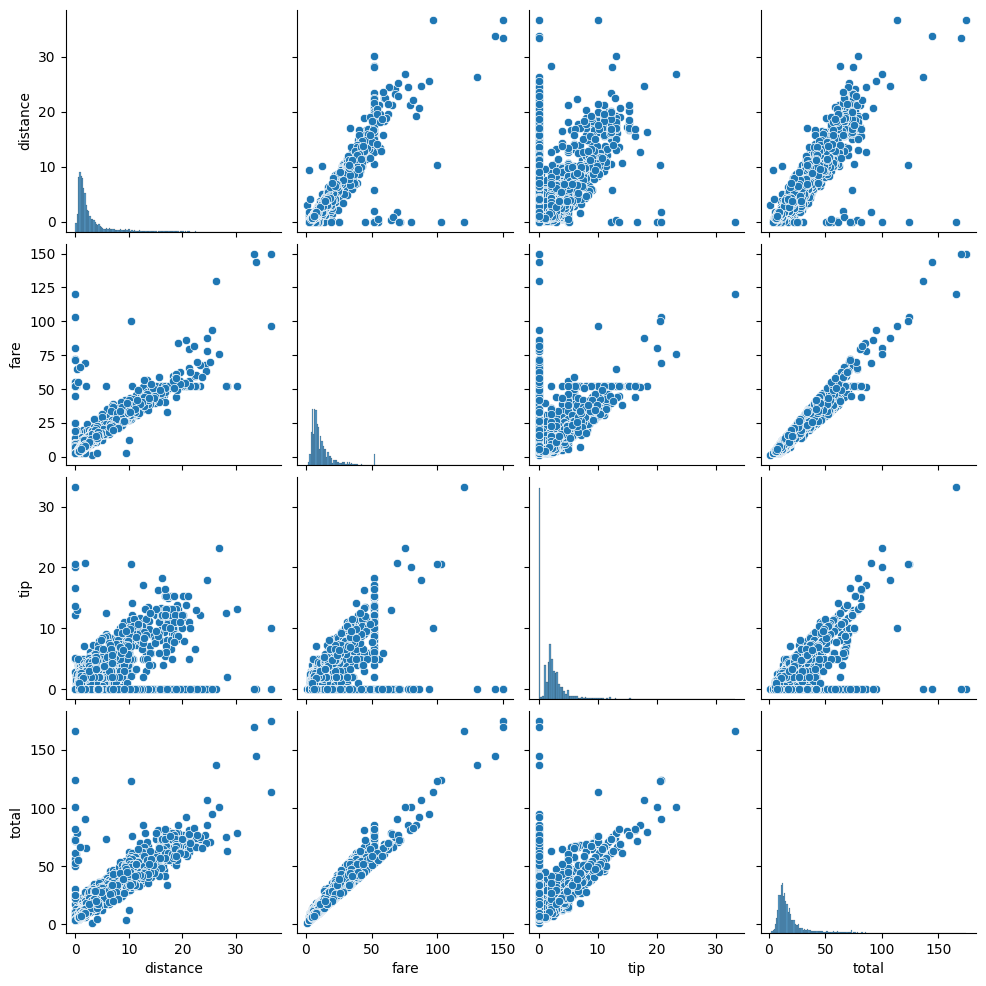

In [14]:
columns = ['distance', 'fare', 'tip', 'total']

sns.pairplot(df[columns])

plt.show()

Violin Plot – Fare by Payment Method

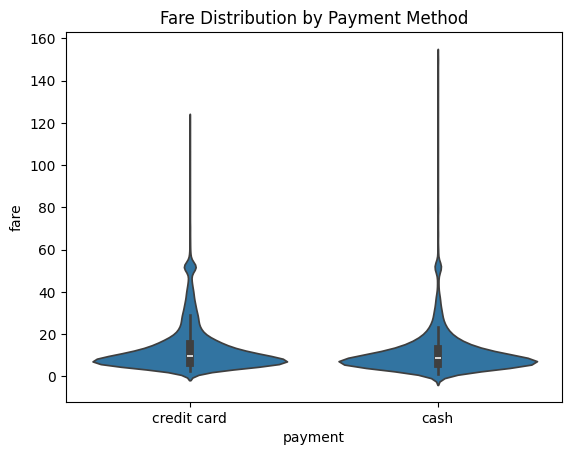

In [15]:
plt.figure()

sns.violinplot(
    x='payment',
    y='fare',
    data=df
)

plt.title("Fare Distribution by Payment Method")
plt.show()